Here is the excerpt from the paper that tells us the values of alpha and beta:


We present our ZTF Hubble diagram for the 2629 non-peculiar SNe~Ia that pass our quality cuts in Figure~6. These SNe~Ia have been standardized using the methodology detailed in Ginolin et~al.~(2024), given the SALT2 stretch and color parameters and host local environmental properties (for example, Sullivan et~al.~2010; Rigault et~al.~2020). Following that paper, we adopt the nuisance parameter values $\alpha = -0.16$, $\beta = 3.05$, and $\gamma = 0.145~\mathrm{mag}$ (local-color step).


The standardized distance modulus for each Type~Ia supernova is computed using the Tripp (1998) relation:

The observed distance modulus in the SALT2 framework is given by: 

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0) + \alpha x_1 - \beta c
$



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import minimize_scalar


In [2]:
# Read the following file:

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop.csv")


# Define the following global parameters:

alpha = 0.161
beta  = 3.05

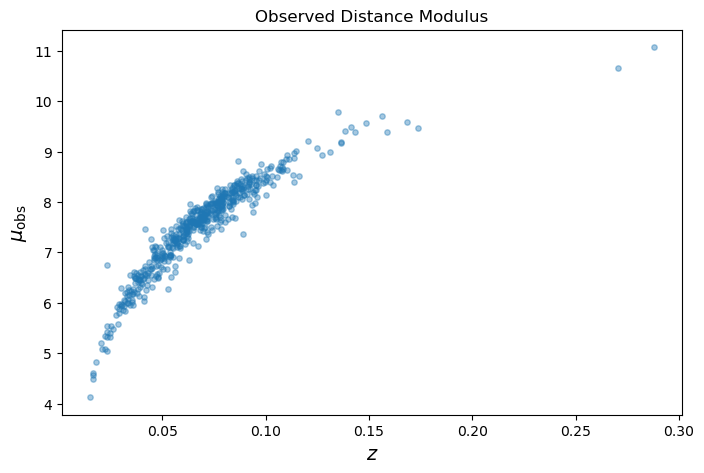

In [3]:
alpha = 0.161
beta  = 3.05

df["mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"]

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4)  # Note desi redshift is used b/c its more percise.
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu_{\mathrm{obs}}$", fontsize=14)
plt.title("Observed Distance Modulus")
plt.show()


# Now We Add Flat Lambda CDM Cosmology For Comparison #

And its plain to see how we need to marginalize for H_o and M_b in order to be able to find the constant that will move our raw data up to the flat lambda CDM cosmology curve that is being defined here. 

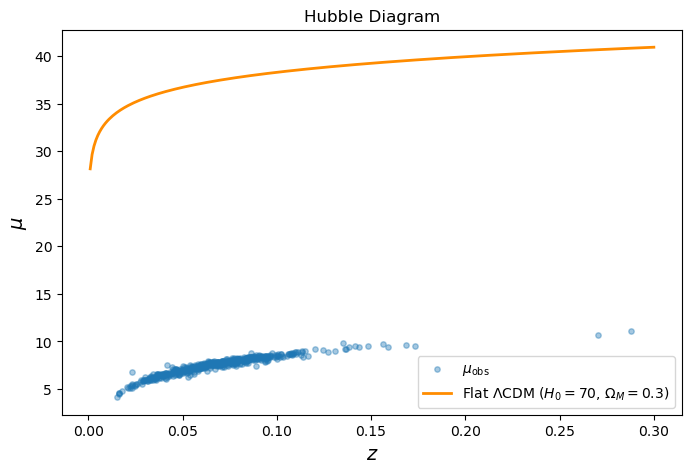

In [4]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z_grid = np.linspace(0.001, 0.3, 300)
mu_grid = cosmo.distmod(z_grid).value

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_grid, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram")
plt.legend()
plt.show()

# Now lets do the error Propagation from the SALT 2 Model Error #

General Form of the Error Propagation Formula for $y = f(x_1, x_2, \ldots, x_n)$

$
\sigma_y^2 =
\sum_{i=1}^{n}
\left(
\frac{\partial f}{\partial x_i}
\right)^2
\sigma_{x_i}^2
+
\sum_{i \ne j}
2\,
\frac{\partial f}{\partial x_i}
\frac{\partial f}{\partial x_j}
\mathrm{Cov}(x_i, x_j).
$

Using the standard error propagation formula:

$$
\sigma_{\mu,\text{obs}} = \sqrt{
\left(\frac{\partial \mu}{\partial x_0}\right)^2 \sigma_{x_0}^2
+\left(\frac{\partial \mu}{\partial x_1}\right)^2 \sigma_{x_1}^2
+\left(\frac{\partial \mu}{\partial c}\right)^2 \sigma_c^2
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial x_1}\right)\mathrm{Cov}(x_0,x_1)
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_0,c)
+ 2\left(\frac{\partial \mu}{\partial x_1}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_1,c)
}
$$


where:

$
\frac{\partial\mu}{\partial x_0} = \frac{-2.5}{x_0\ln 10}
$

$
\frac{\partial\mu}{\partial x_1} = \alpha
$

$
\frac{\partial\mu}{\partial c} = -\beta
$



In [5]:
LN10 = np.log(10)
# Partial derivatives of mu_obs w.r.t. SALT2 parameters
dmu_dx0 = -2.5 / (df["ZTF_x0"] * LN10)
dmu_dx1 = alpha
dmu_dc  = -beta

df["sigma_mu"] = np.sqrt(
    dmu_dx0**2 * df["ZTF_x0_err"]**2
  + dmu_dx1**2 * df["ZTF_x1_err"]**2
  + dmu_dc**2  * df["ZTF_c_err"]**2
  + 2 * dmu_dx0 * dmu_dx1 * df["ZTF_cov_x0_x1"]
  + 2 * dmu_dx0 * dmu_dc  * df["ZTF_cov_x0_c"]
  + 2 * dmu_dx1 * dmu_dc  * df["ZTF_cov_x1_c"]
)
print(df["sigma_mu"].describe())

count    539.000000
mean       0.085315
std        0.026829
min        0.054469
25%        0.067031
50%        0.078496
75%        0.094074
max        0.240867
Name: sigma_mu, dtype: float64


# Now Lets Do $\chi^2$ Minnimization #

Note we start with a redshift (i.e. volume) limited sample of z < 0.06 as was done in prior work with: 

ZTF SN Ia DR2: Colour standardisation of type Ia supernovae and its dependence on the environment M. Ginolin

This is done to get rid of biases that we end up seeing at higher redshifts. Maily malmquist bias. 

We will define our volume limiting via the ZTF repoprted redshift by the way to keep in line with Ginolin et al

We find $\mathscr{M}$ by minimizing:

$\chi^2(\mathscr{M}) = \sum_i \frac{\left(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i} - \mathscr{M}\right)^2}{\sigma_{\mu,i}^2}$


$\mathscr{M}$ is the only free parameter. It absorbs the degenerate combination of $M_B$ and $H_0$. 

Changing $\mathscr{M}$ shifts all $\mu_{\mathrm{obs}}$ by the same constant — the optimizer finds the value that places

 the data on the theory curve (i.e. minimizes the weighted sum of squared residuals).

In [16]:
# Create a new data frame where we only keep SNe with z < 0.06 to construct a volume-limited sample. 
# Note this is done to our data and our sample. We are not using the Ginolin data but rather following in their
# footsteps. 


df_vlim = df[df["ZTF_redshift"] < 0.06].copy()

print(f"Volume-limited sample has: {len(df_vlim)} SNe (z < 0.06)")

# Need to put .value here or it will throw an error. 
mu_th_vlim = cosmo.distmod(df_vlim["ZTF_redshift"]).value

# Construct the chi2 function to minimize. 

def chi2(script_M):
    mu_obs = -2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - script_M
    residuals = mu_obs - mu_th_vlim
    return np.sum(residuals**2 / df_vlim["sigma_mu"]**2)

# Note minimize_scalare takes whatever function I give it and
# minimizes it over that function's single input argument. 
result = minimize_scalar(chi2)
print("\n")
print(result)

Volume-limited sample has: 200 SNe (z < 0.06)


 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 1606.1718056028628
       x: -29.75715284652141
     nit: 4
    nfev: 9


Results of $\chi^2$ Minimization (Volume-Limited Sample)

- **success: True** — optimizer converged, no issues
- **x:** $\mathscr{M} = -29.757$ — best-fit script-M
- **fun:** $\chi^2 = 1606.17$ — minimum chi-squared value
- **nit: 4** — number of iterations it took 
- **nfev: 9** — evaluated the $\chi^2$ function 9 times total

$\chi^2/\mathrm{dof} = 1606 / (200 - 1) = 8.07$. This is high, and indicative of the fact that there 
is a wrong model or variance is not propperly being accounted for. Like there's additional error in this model. 

# Now lets take a look at the Full Sample and see What the Correction Looks Like #

This looks much better. But we end up having som pretty shoddy metrics for the following quantities:

Volume-limited sample: 200 SNe (z < 0.06)
script-M   = -29.7571
chi2       = 1604.82
chi2/dof   = 8.06

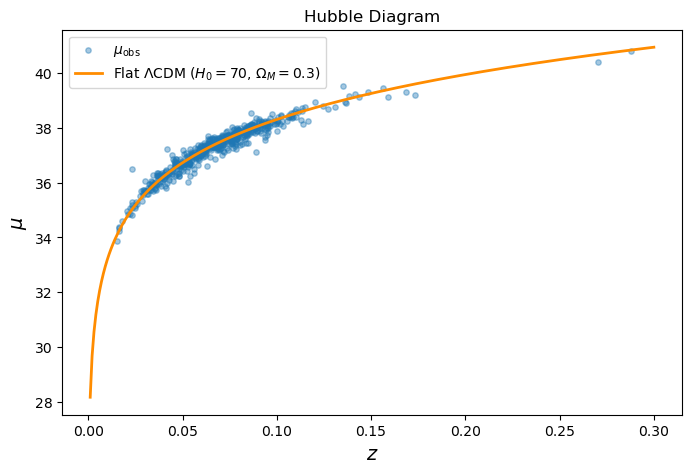

In [7]:

#Redefine our distance modulus with the fitted script-M:
df["mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - scriptM_fit


# Everything else stays the same:
plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_grid, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram")
plt.legend()
plt.show()

# Now lets try to see What Accounting for the Full Error Looks Like #

# Apppendix - Where does $\mathscr{M}$ come from? # 
#

Where does script_M come from. 

### The theory side

Cosmology predicts how far away something is based on its redshift.
The theoretical distance modulus is:

$\mu_{\mathrm{th}}(z) = 5\log_{10}\left(\frac{d_L(z)}{1\;\mathrm{Mpc}}\right) + 25$

where $d_L(z)$ is the luminosity distance. Here's the key:
$d_L$ depends on $H_0$ because:

$d_L(z) = \frac{c(1+z)}{H_0} \int_0^z \frac{dz'}{\sqrt{\Omega_M(1+z')^3 + \Omega_\Lambda}}$

See that $1/H_0$ out front? That means $\mu_{\mathrm{th}}$ contains a
term $-5\log_{10}(H_0) + \mathrm{const}$.

### The observation side

The Tripp equation gives:

$\mu_{\mathrm{obs}} = -2.5\log_{10}(x_0) + \alpha x_1 - \beta c - M_B$

This contains $M_B$ (the absolute magnitude of a "standard" SN Ia).

### The residual

When you compute the Hubble residual:

$\Delta\mu = \mu_{\mathrm{obs}} - \mu_{\mathrm{th}}$

The $M_B$ from the observation side and the $H_0$ from the theory side
combine into a single constant offset. No matter how hard you try, you
cannot separate them — changing $M_B$ by some amount has the exact
same effect as changing $H_0$ by some corresponding amount. This is
the **degeneracy**.

### The solution: script-M

Instead of pretending we know $M_B$ and $H_0$ separately, we define:

$\mathscr{M} = M_B - 5\log_{10}\left(\frac{c/H_0}{1\;\mathrm{Mpc}}\right) + 25$

This is one number that captures both. We don't know what $M_B$ is.
We don't know what $H_0$ is. But we can find the combination that
makes our observed data match the theoretical curve. That's all we need.

# Appendix: Chi-Squared Minimization


The textbook chi-squared statistic is designed for binned count data,
where the expected count serves as the variance estimate:

$\chi^2 = \sum_i \frac{(\mathrm{observed}_i - \mathrm{expected}_i)^2}{\mathrm{expected}_i}$

This form assumes Poisson-distributed counts, where the variance
equals the mean. It is commonly used for goodness-of-fit tests on
histograms and contingency tables
(see https://en.wikipedia.org/wiki/Minimum_chi-square_estimation)).

In our analysis, each data point is a continuous measurement
(distance modulus $\mu_{\mathrm{obs}}$) with its own individually
propagated uncertainty $\sigma_{\mu,i}$ from the SALT2 light-curve
covariance matrix. The appropriate form is:

$\chi^2 = \sum_i \frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{\sigma_{\mu,i}^2}$

The denominator is the variance of each measurement, not the
expected value. This allows well-measured SNe (small $\sigma_\mu$)
to anchor the fit while noisy measurements are downweighted.

The reduced chi-squared normalizes by the degrees of freedom
$\nu = n - m$, where $n$ is the number of data points and $m$
is the number of fitted parameters
(see https://en.wikipedia.org/wiki/Reduced_chi-squared_statistic):

$\chi^2_\nu = \frac{\chi^2}{\nu}$

- $\chi^2_\nu \approx 1$: model adequately describes the data
- $\chi^2_\nu \gg 1$: model is missing error or its a wrong model (e.g., intrinsic scatter) see: https://www.nevis.columbia.edu/~seligman/root-class/html/appendix/statistics/ChiSquaredDOF.html
- $\chi^2_\nu \ll 1$: uncertainties are overestimated




# Just Making a Space to Delimit a Work in Progress Vs. The Final code that should be part of the Fianl Draft out Here #













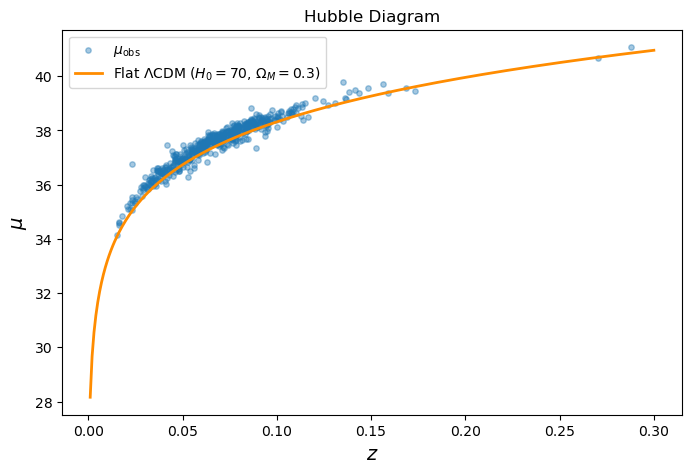

In [8]:
MB = -19.5
df["mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - MB + 10.5

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z_grid = np.linspace(0.001, 0.3, 300)
mu_grid = cosmo.distmod(z_grid).value

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_grid, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram")
plt.legend()
plt.show()

script-M  = -29.7740
sigma_int = 0.1832 mag


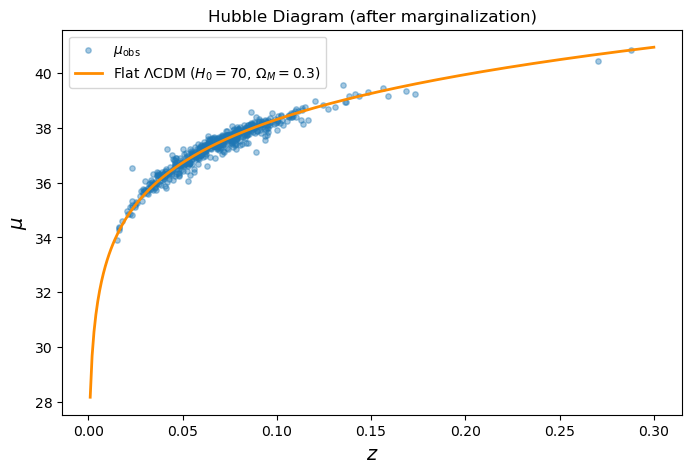

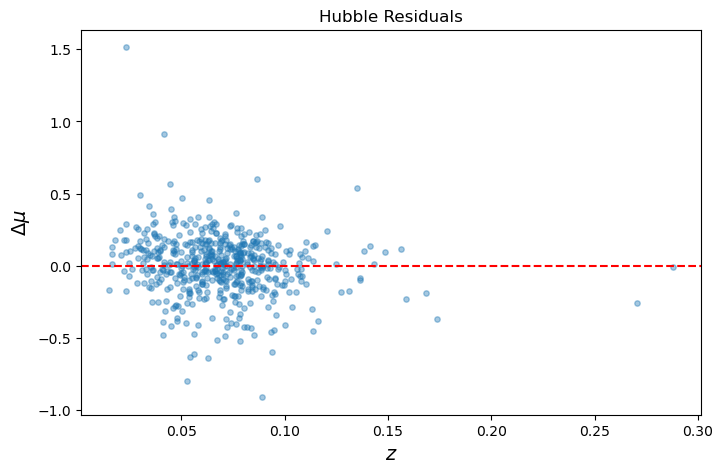

N_SN       = 540
chi2       = 554.40
chi2/dof   = 1.03
-2logL     = -1164.74
script-M   = -29.7740
sigma_int  = 0.1832 mag
Mean resid = 0.0005 mag
Std resid  = 0.2100 mag
nMAD resid = nan mag


In [9]:
from scipy.optimize import minimize

# Adopted from Ginolin et al. (2024)
alpha = 0.161
beta  = 3.05

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
mu_th = cosmo.distmod(df["DESI_METADATA_Z"]).value

# Error propagation
LN10 = np.log(10)
dmu_dx0 = -2.5 / (df["ZTF_x0"] * LN10)
dmu_dx1 = alpha
dmu_dc  = -beta

sigma_mu = np.sqrt(
    dmu_dx0**2 * df["ZTF_x0_err"]**2
  + dmu_dx1**2 * df["ZTF_x1_err"]**2
  + dmu_dc**2  * df["ZTF_c_err"]**2
  + 2 * dmu_dx0 * dmu_dx1 * df["ZTF_cov_x0_x1"]
  + 2 * dmu_dx0 * dmu_dc  * df["ZTF_cov_x0_c"]
  + 2 * dmu_dx1 * dmu_dc  * df["ZTF_cov_x1_c"]
)

# Negative log-likelihood: fit script-M and sigma_int
def neg_loglike(params):
    script_M, sigma_int = params
    mu_obs = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - script_M
    sigma_total = np.sqrt(sigma_mu**2 + sigma_int**2)
    residuals = mu_obs - mu_th
    return np.sum(residuals**2 / sigma_total**2) + np.sum(2 * np.log(sigma_total))

result = minimize(neg_loglike, [19.5, 0.12], method="Nelder-Mead")
scriptM_fit, sigma_int_fit = result.x

print(f"script-M  = {scriptM_fit:.4f}")
print(f"sigma_int = {sigma_int_fit:.4f} mag")

# Final residuals
df["mu_obs"]      = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - scriptM_fit
df["mu_th"]        = mu_th
df["residual"]     = df["mu_obs"] - df["mu_th"]
df["sigma_mu"]     = sigma_mu
df["sigma_total"]  = np.sqrt(sigma_mu**2 + sigma_int_fit**2)

# Hubble diagram
z_grid = np.linspace(0.001, 0.3, 300)
mu_grid = cosmo.distmod(z_grid).value

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_grid, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram (after marginalization)")
plt.legend()
plt.show()

# Residuals
plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["residual"], s=15, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\Delta\mu$", fontsize=14)
plt.title("Hubble Residuals")
plt.show()

# Quality of fit diagnostics
N = len(df)
n_params = 2  # script-M and sigma_int

chi2 = np.sum(df["residual"]**2 / df["sigma_total"]**2)
print(f"N_SN       = {N}")
print(f"chi2       = {chi2:.2f}")
print(f"chi2/dof   = {chi2 / (N - n_params):.2f}")
print(f"-2logL     = {result.fun:.2f}")
print(f"script-M   = {scriptM_fit:.4f}")
print(f"sigma_int  = {sigma_int_fit:.4f} mag")
print(f"Mean resid = {df['residual'].mean():.4f} mag")
print(f"Std resid  = {df['residual'].std():.4f} mag")
print(f"nMAD resid = {1.4826 * np.median(np.abs(df['residual'] - np.median(df['residual']))):.4f} mag")

# Chi squared only #

script-M  = -29.7758


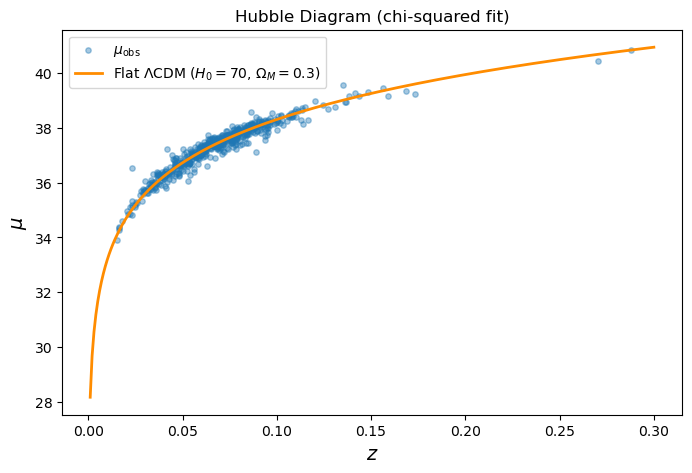

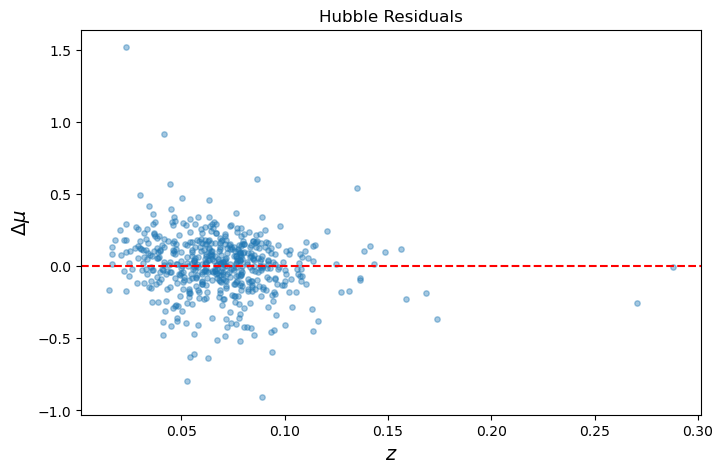

N_SN       = 540
chi2       = 3312.16
chi2/dof   = 6.15
script-M   = -29.7758
Mean resid = 0.0022 mag
Std resid  = 0.2100 mag


In [10]:
from scipy.optimize import minimize_scalar

# Adopted from Ginolin et al. (2024)
alpha = 0.161
beta  = 3.05

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
mu_th = cosmo.distmod(df["DESI_METADATA_Z"]).value

# Error propagation
LN10 = np.log(10)
dmu_dx0 = -2.5 / (df["ZTF_x0"] * LN10)
dmu_dx1 = alpha
dmu_dc  = -beta

sigma_mu = np.sqrt(
    dmu_dx0**2 * df["ZTF_x0_err"]**2
  + dmu_dx1**2 * df["ZTF_x1_err"]**2
  + dmu_dc**2  * df["ZTF_c_err"]**2
  + 2 * dmu_dx0 * dmu_dx1 * df["ZTF_cov_x0_x1"]
  + 2 * dmu_dx0 * dmu_dc  * df["ZTF_cov_x0_c"]
  + 2 * dmu_dx1 * dmu_dc  * df["ZTF_cov_x1_c"]
)

# Plain chi-squared: fit script-M only
def chi2(script_M):
    mu_obs = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - script_M
    residuals = mu_obs - mu_th
    return np.sum(residuals**2 / sigma_mu**2)

result = minimize_scalar(chi2, bounds=(-35, -25), method="bounded")
scriptM_fit = result.x

print(f"script-M  = {scriptM_fit:.4f}")

# Final residuals
df["mu_obs"]    = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - scriptM_fit
df["mu_th"]     = mu_th
df["residual"]  = df["mu_obs"] - df["mu_th"]
df["sigma_mu"]  = sigma_mu

# Hubble diagram
z_grid = np.linspace(0.001, 0.3, 300)
mu_grid = cosmo.distmod(z_grid).value

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_grid, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram (chi-squared fit)")
plt.legend()
plt.show()

# Residuals
plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["residual"], s=15, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\Delta\mu$", fontsize=14)
plt.title("Hubble Residuals")
plt.show()

# Quality of fit diagnostics
N = len(df)
n_params = 1  # script-M only

chi2_val = np.sum(df["residual"]**2 / df["sigma_mu"]**2)
print(f"N_SN       = {N}")
print(f"chi2       = {chi2_val:.2f}")
print(f"chi2/dof   = {chi2_val / (N - n_params):.2f}")
print(f"script-M   = {scriptM_fit:.4f}")
print(f"Mean resid = {df['residual'].mean():.4f} mag")
print(f"Std resid  = {df['residual'].std():.4f} mag")

# Including MB #

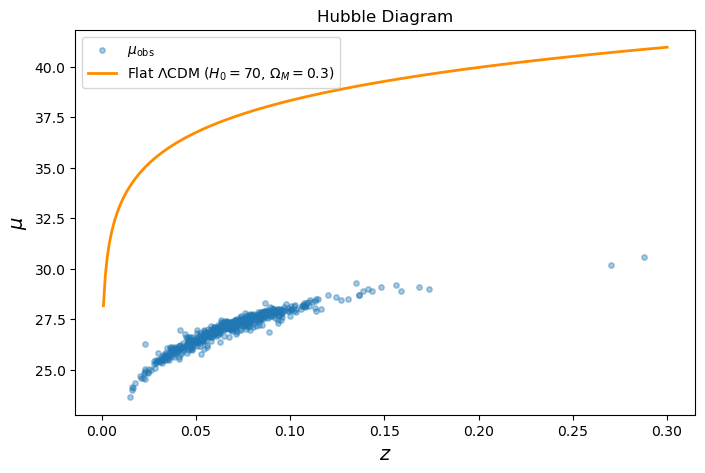

In [11]:
MB = -19.5
df["mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - MB

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z_grid = np.linspace(0.001, 0.3, 300)
mu_grid = cosmo.distmod(z_grid).value

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_grid, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram")
plt.legend()
plt.show()

# Marginalization #


# Marginalization over $M_B$ and $H_0$

The absolute magnitude $M_B$ and the Hubble constant $H_0$ are completely
degenerate in SN Ia data — they enter the distance modulus only through
the combination:

$$\mathscr{M} = M_B - 5\log_{10}\left(\frac{c/H_0}{1\;\mathrm{Mpc}}\right) + 25$$

We cannot measure either one individually from SNe alone. Instead, we fit
for $\mathscr{M}$ as a single free parameter alongside the intrinsic
scatter $\sigma_{\mathrm{int}}$ by minimizing the negative log-likelihood:

$$-2\ln\mathcal{L} = \sum_i \left[\frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{\sigma_{\mathrm{total},i}^2} + 2\ln(\sigma_{\mathrm{total},i})\right]$$

where $\sigma_{\mathrm{total},i}^2 = \sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2$.

This is the marginalization: fitting $\mathscr{M}$ absorbs the $M_B / H_0$
degeneracy, and $\sigma_{\mathrm{int}}$ accounts for the irreducible
scatter beyond measurement noise.

script-M  = -29.7740
sigma_int = 0.1832 mag


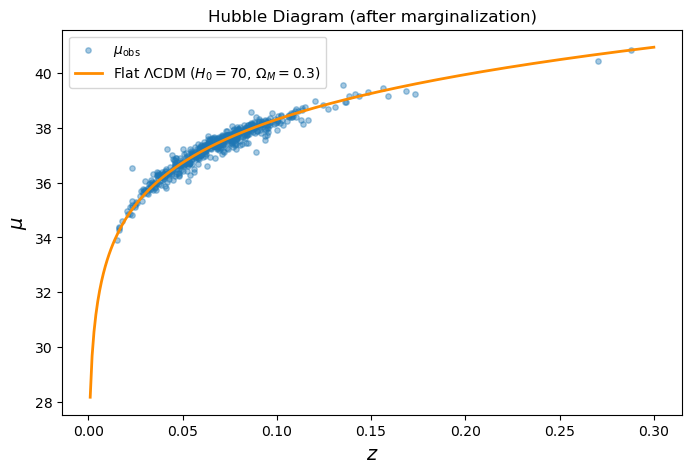

In [12]:
from scipy.optimize import minimize

# Alpha and beta adopted from Ginolin et al. (2024)
alpha = 0.161
beta  = 3.05

# Cosmology for mu_th
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
mu_th = cosmo.distmod(df["DESI_METADATA_Z"]).value

# --- sigma_mu from SALT2 covariance matrix ---
def compute_sigma_mu(df, alpha, beta):
    dmudx0 = -2.5 / (df["ZTF_x0"] * np.log(10))
    dmudx1 = alpha
    dmudc  = -beta

    sigma_mu_sq = (
        dmudx0**2 * df["ZTF_x0_err"]**2
      + dmudx1**2 * df["ZTF_x1_err"]**2
      + dmudc**2  * df["ZTF_c_err"]**2
      + 2 * dmudx0 * dmudx1 * df["ZTF_cov_x0_x1"]
      + 2 * dmudx0 * dmudc  * df["ZTF_cov_x0_c"]
      + 2 * dmudx1 * dmudc  * df["ZTF_cov_x1_c"]
    )
    return np.sqrt(sigma_mu_sq)

sigma_mu = compute_sigma_mu(df, alpha, beta)

# --- Negative log-likelihood ---
def neg_loglike(params):
    script_M, sigma_int = params

    mu_obs = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - script_M
    sigma_total = np.sqrt(sigma_mu**2 + sigma_int**2)
    residuals = mu_obs - mu_th

    return np.sum(residuals**2 / sigma_total**2) + np.sum(2 * np.log(sigma_total))

# --- Fit ---
result = minimize(neg_loglike, [19.5, 0.12], method="Nelder-Mead")
scriptM_fit, sigma_int_fit = result.x

print(f"script-M  = {scriptM_fit:.4f}")
print(f"sigma_int = {sigma_int_fit:.4f} mag")

# --- Compute final mu_obs and residuals ---
df["mu_obs"]    = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - scriptM_fit
df["mu_th"]     = mu_th
df["residual"]  = df["mu_obs"] - df["mu_th"]
df["sigma_mu"]  = sigma_mu
df["sigma_total"] = np.sqrt(sigma_mu**2 + sigma_int_fit**2)

# --- Plot: does the data sit on the curve now? ---
z_grid = np.linspace(0.001, 0.3, 300)
mu_grid = cosmo.distmod(z_grid).value

plt.figure(figsize=(8, 5))
plt.scatter(df["DESI_METADATA_Z"], df["mu_obs"], s=15, alpha=0.4, label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_grid, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title("Hubble Diagram (after marginalization)")
plt.legend()
plt.show()

# Cosmology Lesson: Script-M and Log-Likelihood Marginalization

## Part 1: Why do we need script-M?

### The problem

When you observe a SN Ia, you measure how bright it appears (apparent
magnitude). To figure out how far away it is, you need to know how
bright it actually is (absolute magnitude, $M_B$). The distance
modulus connects the two:

$$\mu = m - M$$

where $m$ is apparent magnitude and $M$ is absolute magnitude. Bigger
$\mu$ = farther away.

### The theory side

Cosmology predicts how far away something is based on its redshift.
The theoretical distance modulus is:

$$\mu_{\mathrm{th}}(z) = 5\log_{10}\left(\frac{d_L(z)}{1\;\mathrm{Mpc}}\right) + 25$$

where $d_L(z)$ is the luminosity distance. Here's the key:
$d_L$ depends on $H_0$ because:

$$d_L(z) = \frac{c(1+z)}{H_0} \int_0^z \frac{dz'}{\sqrt{\Omega_M(1+z')^3 + \Omega_\Lambda}}$$

See that $1/H_0$ out front? That means $\mu_{\mathrm{th}}$ contains a
term $-5\log_{10}(H_0) + \mathrm{const}$.

### The observation side

The Tripp equation gives:

$$\mu_{\mathrm{obs}} = -2.5\log_{10}(x_0) + \alpha x_1 - \beta c - M_B$$

This contains $M_B$ (the absolute magnitude of a "standard" SN Ia).

### The residual

When you compute the Hubble residual:

$$\Delta\mu = \mu_{\mathrm{obs}} - \mu_{\mathrm{th}}$$

The $M_B$ from the observation side and the $H_0$ from the theory side
combine into a single constant offset. No matter how hard you try, you
cannot separate them — changing $M_B$ by some amount has the exact
same effect as changing $H_0$ by some corresponding amount. This is
the **degeneracy**.

### The solution: script-M

Instead of pretending we know $M_B$ and $H_0$ separately, we define:

$$\mathscr{M} = M_B - 5\log_{10}\left(\frac{c/H_0}{1\;\mathrm{Mpc}}\right) + 25$$

This is one number that captures both. We don't know what $M_B$ is.
We don't know what $H_0$ is. But we can find the **combination** that
makes our observed data match the theoretical curve. That's all we need.

### Analogy

Imagine you're measuring the height of a table, but your ruler starts
at some unknown offset (you can't see the zero mark). You can't measure
absolute height, but you can measure **differences** in height between
objects on the table perfectly well. Script-M is that unknown offset.
Once you subtract it out (or fit for it), all relative measurements
are valid.

---

## Part 2: What is a likelihood?

### Starting from probability

Say you measure one SN Ia. You observe $\mu_{\mathrm{obs}}$ and the
theory predicts $\mu_{\mathrm{th}}$. If the measurement has Gaussian
uncertainty $\sigma$, then the probability of getting your observed
value is:

$$P(\mu_{\mathrm{obs}} | \mu_{\mathrm{th}}, \sigma) = \frac{1}{\sqrt{2\pi}\,\sigma} \exp\left(-\frac{(\mu_{\mathrm{obs}} - \mu_{\mathrm{th}})^2}{2\sigma^2}\right)$$

This is just a Gaussian bell curve centered on $\mu_{\mathrm{th}}$.

### Many SNe

For $N$ independent SNe, the total probability of observing ALL of
them is the product:

$$\mathcal{L} = \prod_{i=1}^{N} \frac{1}{\sqrt{2\pi}\,\sigma_i} \exp\left(-\frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{2\sigma_i^2}\right)$$

This product is called the **likelihood** ($\mathcal{L}$). It answers:
"how likely is it that I'd see my data, given my model parameters?"

### Why take the log?

Products of hundreds of tiny numbers are numerically awful (underflow).
Taking the log turns products into sums:

$$\ln\mathcal{L} = \sum_i \left[-\frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{2\sigma_i^2} - \frac{1}{2}\ln(2\pi) - \ln(\sigma_i)\right]$$

We want to **maximize** this (find the parameters that make the data
most likely). Equivalently, we **minimize** the negative:

$$-2\ln\mathcal{L} = \sum_i \left[\frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{\sigma_i^2} + 2\ln(\sigma_i)\right] + \mathrm{const}$$

(We dropped the $\ln(2\pi)$ constant because it doesn't depend on
parameters and doesn't affect where the minimum is.)

### Why not just use chi-squared?

If $\sigma_i$ is fixed (doesn't depend on the parameters you're
fitting), then the $2\ln(\sigma_i)$ term is also a constant and you
can drop it. Then $-2\ln\mathcal{L} = \chi^2 + \mathrm{const}$, and
minimizing the log-likelihood IS the same as minimizing chi-squared.

But in our case, $\sigma_{\mathrm{total}} = \sqrt{\sigma_\mu^2 + \sigma_{\mathrm{int}}^2}$,
and $\sigma_{\mathrm{int}}$ is a free parameter. So $\sigma_i$
changes during the fit. Without the $2\ln(\sigma_i)$ penalty, the
optimizer would just set $\sigma_{\mathrm{int}} = \infty$ to make
all the residuals negligible compared to the error bars, giving
$\chi^2 \to 0$. The log term prevents this by penalizing large
error bars.

---

## Part 3: What does "marginalization" actually mean?

In Bayesian statistics, marginalization means: "I don't care about
this parameter, so I integrate over all its possible values."

In practice, for script-M, we're doing something simpler: we're
**profiling** — finding the single best-fit value of $\mathscr{M}$
that maximizes the likelihood. For a Gaussian likelihood (which ours
is), profiling and marginalizing give the same answer.

The point is: we never claim to know $M_B$ or $H_0$. We just find
the value of their combination ($\mathscr{M}$) that best fits the
data. Our Hubble residuals $\Delta\mu$ then depend on $\mathscr{M}$,
but since $\mathscr{M}$ is the same constant for every SN, it shifts
all residuals by the same amount. Any analysis that looks at
**relative differences** between SNe (which is what your ML does) is
completely independent of $\mathscr{M}$, and therefore independent of
both $M_B$ and $H_0$.

---

## Part 4: Summary of what the code does

1. **Pick trial values** of $\mathscr{M}$ and $\sigma_{\mathrm{int}}$
2. **Compute** $\mu_{\mathrm{obs}}$ using the Tripp equation with
   the trial $\mathscr{M}$
3. **Compute** residuals $= \mu_{\mathrm{obs}} - \mu_{\mathrm{th}}$
4. **Compute** $\sigma_{\mathrm{total}} = \sqrt{\sigma_\mu^2 + \sigma_{\mathrm{int}}^2}$
5. **Compute** $-2\ln\mathcal{L}$: reward small residuals, penalize
   large error bars
6. **Repeat** with new trial values until the minimum is found
7. **Output**: the best-fit $\mathscr{M}$ and $\sigma_{\mathrm{int}}$

The optimizer (Nelder-Mead) handles step 6 automatically. You just
give it the function and starting guesses. It tries hundreds of
combinations and returns the one that minimizes $-2\ln\mathcal{L}$.

# Chi-Squared Minimization: The Simple Version

## What is chi-squared?

You have data. You have a model with free parameters. Chi-squared
measures how badly the model disagrees with the data:

$$\chi^2 = \sum_i \frac{(\mathrm{data}_i - \mathrm{model}_i)^2}{\sigma_i^2}$$

Each term asks: "how many sigma away is this data point from
the model prediction?"

- Data point sits right on the model → contributes 0
- Data point is 1σ away → contributes 1
- Data point is 3σ away → contributes 9

Add them all up. Smaller χ² = better fit.

## In our case

Our data is $\mu_{\mathrm{obs},i}$ (observed distance modulus for
each SN). Our model is $\mu_{\mathrm{th},i}$ (what cosmology
predicts for that SN's redshift). The uncertainty is $\sigma_{\mu,i}$
(propagated from SALT2). The free parameter is $\mathscr{M}$
(script-M).

$$\chi^2(\mathscr{M}) = \sum_i \frac{(\mu_{\mathrm{obs},i}(\mathscr{M}) - \mu_{\mathrm{th},i})^2}{\sigma_{\mu,i}^2}$$

Notice that $\mu_{\mathrm{obs}}$ depends on $\mathscr{M}$:

$$\mu_{\mathrm{obs}} = -2.5\log_{10}(x_0) + \alpha x_1 - \beta c - \mathscr{M}$$

So changing $\mathscr{M}$ shifts ALL the $\mu_{\mathrm{obs}}$ values
up or down by the same amount.

## What the optimizer does

Imagine $\mathscr{M}$ is a knob. You turn it:

- Too low → all $\mu_{\mathrm{obs}}$ are too high → data sits above
  the theory curve → residuals are positive → χ² is large
- Too high → all $\mu_{\mathrm{obs}}$ are too low → data sits below
  the theory curve → residuals are negative → χ² is large
- Just right → data sits on the curve → residuals scatter around
  zero → χ² is minimized

The optimizer turns the knob until χ² is as small as possible.
That's it. That's the whole thing.

## Why weight by σ²?

Without weights:

$$\chi^2 = \sum_i (\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2$$

Every SN counts equally. A noisy SN measured with σ = 1.0 mag has
the same pull on the fit as a clean SN measured with σ = 0.05 mag.
That's dumb.

With weights:

$$\chi^2 = \sum_i \frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{\sigma_i^2}$$

The clean SN (small σ) contributes a big number if it doesn't fit.
The noisy SN (large σ) contributes almost nothing either way. The
fit is anchored by the well-measured objects. That's smart.

## What is χ²/dof?

After fitting, divide χ² by the degrees of freedom
(dof = number of data points − number of free parameters):

- **χ²/dof ≈ 1** → model fits well. The residuals are the size
  you'd expect given the uncertainties.
- **χ²/dof >> 1** → model is missing something. Either the model
  is wrong, or the error bars are too small (this is where
  σ_int would come in — but we're ignoring it for now).
- **χ²/dof << 1** → error bars are too large. You're overfitting
  or overestimating uncertainties.

## The code
```python
from scipy.optimize import minimize_scalar

sigma_mu = compute_sigma_mu(df, alpha, beta)
mu_th = cosmo.distmod(df["DESI_METADATA_Z"]).value

def chi2(scriptM):
    mu_obs = (-2.5 * np.log10(df["ZTF_x0"])
              + alpha * df["ZTF_x1"]
              - beta * df["ZTF_c"]
              - scriptM)
    return np.sum((mu_obs - mu_th)**2 / sigma_mu**2)

result = minimize_scalar(chi2, bounds=(-35, -25), method="bounded")
print(f"script-M = {result.x:.4f}")
print(f"chi2     = {result.fun:.2f}")
print(f"chi2/dof = {result.fun / (len(df) - 1):.2f}")
```

We use `minimize_scalar` here because there's only one free
parameter (script-M). No need for Nelder-Mead — scalar
minimization is faster and guaranteed to find the answer.

## After the fit
```python
df["mu_obs"]   = (-2.5 * np.log10(df["ZTF_x0"])
                  + alpha * df["ZTF_x1"]
                  - beta * df["ZTF_c"]
                  - result.x)
df["residual"] = df["mu_obs"] - mu_th
```

These residuals are your ML target variable. They're independent
of $M_B$ and $H_0$ because script-M absorbed both.

## When is this NOT enough?

When χ²/dof >> 1. That means the scatter in the data is larger
than what $\sigma_\mu$ alone predicts. The fix is adding intrinsic
scatter $\sigma_{\mathrm{int}}$ — but then $\sigma$ becomes a free
parameter, the log(σ) penalty term matters, and you need the full
log-likelihood instead of plain chi-squared. That's the "proper"
version we coded earlier.

In [13]:
# Compute theoretical distance modulus for each SN using its redshift
df["mu_theory"] = cosmo.distmod(df["redshift"]).value

# Compute Hubble residuals (observed - theoretical)
df["residual"] = df["mu_obs"] - df["mu_theory"]

# Quick sanity check
print(df[["ztfname", "redshift", "mu_obs", "mu_theory", "residual"]].head())

# Plot residuals vs redshift
plt.figure(figsize=(7,5))
plt.scatter(df["redshift"], df["residual"], s=25, alpha=0.5, color="darkgreen")
plt.axhline(0, color="red", linestyle="--", label="No residual (perfect model)")
plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel(r"Hubble Residual $\Delta\mu = \mu_{\mathrm{obs}} - \mu_{\Lambda \mathrm{CDM}}$", fontsize=12)
plt.title("Hubble Residuals for ZTF SNe Ia", fontsize=14)
plt.legend()
plt.show()

KeyError: 'redshift'

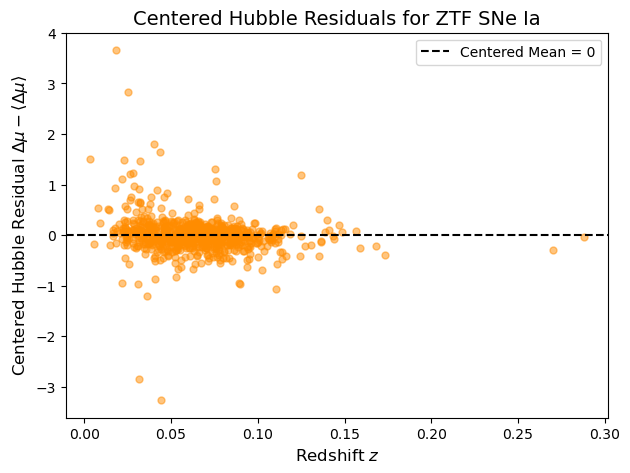

In [ ]:
mean_residual = df["residual"].mean()

# Subtract the mean residual (center the residuals)
df["residual_centered"] = df["residual"] - mean_residual

# Plot centered residuals
plt.figure(figsize=(7,5))
plt.scatter(df["redshift"], df["residual_centered"], s=25, alpha=0.5, color="darkorange")
plt.axhline(0, color="black", linestyle="--", label="Centered Mean = 0")
plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel(r"Centered Hubble Residual $\Delta\mu - \langle\Delta\mu\rangle$", fontsize=12)
plt.title("Centered Hubble Residuals for ZTF SNe Ia", fontsize=14)
plt.legend()
plt.show()

In [ ]:
df.to_csv("ZTF_DESI_data/ZTF_resid_cent_hostprop_with_x1_c.csv", index=False)

# Chi-Squared Minimization for SN Ia Hubble Residuals

## What are we doing?

We have ~540 SNe Ia with SALT2 light-curve parameters ($x_0$, $x_1$, $c$) and redshifts. We want to compute Hubble residuals: how much brighter or fainter each SN is compared to what cosmology predicts.

The **Tripp equation** gives the observed distance modulus:

$$\mu_{\mathrm{obs}} = -2.5\log_{10}(x_0) + \alpha x_1 - \beta c - \mathscr{M}$$

where:
- $-2.5\log_{10}(x_0) = m_B$ (peak apparent magnitude)
- $\alpha$ = stretch-luminosity coefficient (brighter SNe have wider light curves)
- $\beta$ = color-luminosity coefficient (brighter SNe are bluer)
- $\mathscr{M}$ = constant absorbing $M_B$ and $H_0$ (see below)

We **adopt** $\alpha = 0.161$ and $\beta = 3.05$ from Ginolin et al. (2024), who measured them from a larger, volume-limited, Malmquist-free ZTF DR2 sample.

We **fit** $\mathscr{M}$ and $\sigma_{\mathrm{int}}$ from our own data.

---

## What is $\mathscr{M}$ (script-M)?

$M_B$ (absolute magnitude) and $H_0$ (Hubble constant) are completely degenerate in SN Ia data — you can't measure one without knowing the other. They enter the equations only through the combination:

$$\mathscr{M} = M_B - 5\log_{10}\left(\frac{c/H_0}{1\;\mathrm{Mpc}}\right) + 25$$

By fitting $\mathscr{M}$ as a single free parameter, we **marginalize over both $M_B$ and $H_0$ simultaneously**. This is what MWV asked for.

Then when we center the residuals ($\Delta\mu - \langle\Delta\mu\rangle$), $\mathscr{M}$ cancels entirely → results are independent of $M_B$ and $H_0$.

---

## How does the fit work?

We minimize the negative log-likelihood:

$$-2\ln\mathcal{L} = \sum_i \left[\frac{(\mu_{\mathrm{obs},i} - \mu_{\mathrm{th},i})^2}{\sigma_{\mathrm{total},i}^2} + 2\ln(\sigma_{\mathrm{total},i})\right]$$

where:
- $\mu_{\mathrm{th}}(z)$ = theoretical distance modulus from flat $\Lambda$CDM ($\Omega_M = 0.3$, $H_0 = 70$)
- $\sigma_{\mathrm{total},i}^2 = \sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2$
- First term = classic $\chi^2$ (reward fitting the data)
- Second term = penalty for inflating error bars (prevents $\sigma_{\mathrm{int}} \to \infty$)

---

## Error propagation: where does $\sigma_\mu$ come from?

Since $\mu_{\mathrm{obs}}$ is a function of $x_0$, $x_1$, $c$, we propagate using $\sigma^2 = \mathbf{J}\mathbf{C}\mathbf{J}^T$:

$$\sigma_\mu^2 = \left(\frac{-2.5}{x_0\ln 10}\right)^2 \sigma_{x_0}^2 + \alpha^2\sigma_{x_1}^2 + \beta^2\sigma_c^2 + 2\left(\frac{-2.5}{x_0\ln 10}\right)\alpha\;\mathrm{cov}(x_0,x_1) + 2\left(\frac{-2.5}{x_0\ln 10}\right)(-\beta)\;\mathrm{cov}(x_0,c) + 2\alpha(-\beta)\;\mathrm{cov}(x_1,c)$$

All of these quantities ($\sigma_{x_0}$, $\sigma_{x_1}$, $\sigma_c$, and the

In [ ]:
import pandas as pd
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import minimize

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop.csv")
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# --- Step 1: Compute sigma_mu from SALT2 covariance matrix ---
# Partials of mu_obs = -2.5*log10(x0) + alpha*x1 - beta*c
# d(mu)/d(x0) = -2.5 / (x0 * ln(10))
# d(mu)/d(x1) = alpha
# d(mu)/d(c)  = -beta

def compute_sigma_mu(df, alpha, beta):
    dmudx0 = -2.5 / (df["ZTF_x0"] * np.log(10))
    dmudx1 = alpha
    dmudc  = -beta

    sigma_mu_sq = (
        dmudx0**2 * df["ZTF_x0_err"]**2
      + dmudx1**2 * df["ZTF_x1_err"]**2
      + dmudc**2  * df["ZTF_c_err"]**2
      + 2 * dmudx0 * dmudx1 * df["ZTF_cov_x0_x1"]
      + 2 * dmudx0 * dmudc  * df["ZTF_cov_x0_c"]
      + 2 * dmudx1 * dmudc  * df["ZTF_cov_x1_c"]
    )
    return np.sqrt(sigma_mu_sq)

# --- Step 2: Chi-squared minimization with intrinsic scatter ---
mu_th = cosmo.distmod(df["ZTF_redshift"]).value

def compute_neg_loglike(params):
    alpha, beta, script_M, sigma_int = params

    mu_obs = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"] - script_M
    sigma_mu = compute_sigma_mu(df, alpha, beta)
    sigma_total = np.sqrt(sigma_mu**2 + sigma_int**2)

    residuals = mu_obs - mu_th
    neg_loglike = np.sum(residuals**2 / sigma_total**2) + np.sum(2 * np.log(sigma_total))

    return neg_loglike

# Starting guesses (4 parameters now)
x0 = [0.16, 3.05, 19.5, 0.12]

result = minimize(compute_neg_loglike, x0, method="Nelder-Mead")

alpha_fit, beta_fit, scriptM_fit, sigma_int_fit = result.x
print(f"alpha      = {alpha_fit:.4f}")
print(f"beta       = {beta_fit:.4f}")
print(f"scriptM    = {scriptM_fit:.4f}")
print(f"sigma_int  = {sigma_int_fit:.4f}")
print(f"-2logL     = {result.fun:.2f}")
print(f"N_SN       = {len(df)}")

alpha      = 0.1480
beta       = 2.7915
scriptM    = -29.7660
sigma_int  = 0.1836
-2logL     = -1181.82
N_SN       = 540
